# Pronóstico de la Tasa Representativa del Mercado: modelos ARIMA, SARIMA y GARCH

En este notebook se integra el desarrollo de las unidades previas del proyecto sobre la Tasa Representativa del Mercado (TRM). En la unidad 1 se estableció que la serie en nivel no es estacionaria y que su primeria diferencia logarítmica sí lo es, mientras que en la unidad 2 se identificó un modelo MA(1) sobre el log retorno del promedio mensual, cuya estructura se asoció al efecto de agregación temporal (Working, 1960). A partir de esto, en esta unidad se incorporan los modelos ARIMA y SARIMA en la identificación, se revisan los rezagos estacionales de la serie, se incluyen los modelos ARCH y GARCH para la varianza y finalmente se evalúa la capacidad del modelo del avance 2 y del modelo final frente a una caminara aleatoria.

**Fuente de datos:** Banco de la República (2026). Serie diaria de la TRM, noviembre de 1991 a agosto de 2026.


---
## Preparación del entorno

La estimación de los modelos ARIMA y SARIMA se realiza con statsmodels (Seabold & Perkold, 2010) y la de los modelos GARCH con la librería arch (Sheppard, 2025).

In [10]:
import warnings
warnings.filterwarnings("ignore")

# Manejo de datos
import itertools
import numpy as np
import pandas as pd
from scipy import stats

# Visualización 
import matplotlib.pyplot as plt
import seaborn as sns

# Series de tiempo
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from arch import arch_model

# Metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Construcción de la serie mensual

La TRM se calcula como el promedio ponderado de las operaciones de compra y venta de dólares de cada jornada (Banco de la República, 2018), y al igual que en la unidad 2, la serie de trabajo corresponde a su promedio mensual. Antes de calcularlo se verifica que cada mes cuente con la totalidad de sus días, ya que un promedio construido con pocos días no es comparable con el de un mes completo.


In [11]:
url = ("https://raw.githubusercontent.com/Juanhv24/Time-Series-Colombia/"
       "main/data/raw/Tasa%20de%20cambio%20del%20peso%20colombiano.csv")

trm = pd.read_csv(url)
trm.columns = ["fecha", "trm"]
trm["fecha"] = pd.to_datetime(trm["fecha"], format="%Y/%m/%d")
trm = trm.sort_values("fecha").set_index("fecha")["trm"]

# Días con dato frente a días calendario de cada mes
dias = trm.resample("MS").size()
completo = dias == dias.index.days_in_month

incompletos = pd.DataFrame({"días con dato": dias[~completo],
                            "días del mes": dias[~completo].index.days_in_month})
print("Meses incompletos")
print(incompletos.to_string())

# Log-retorno del primer mes con el promedio de noviembre de 1991 incluido
promedio_todos = trm.resample("MS").mean()
primer_retorno = 100 * np.log(promedio_todos.iloc[1] / promedio_todos.iloc[0])
print(f"\nLog-retorno de diciembre de 1991 frente al promedio de 4 días de noviembre: {primer_retorno:.2f}")

Meses incompletos
            días con dato  días del mes
fecha                                  
1991-11-01              4            30
2026-08-01             28            31

Log-retorno de diciembre de 1991 frente al promedio de 4 días de noviembre: -9.64


In [12]:
# Promedio mensual sobre meses completos, en logaritmo y escala porcentual
trm_mensual = trm.resample("MS").mean()[completo]
X = 100 * np.log(trm_mensual)
X.index.freq = "MS"

# Primeria diferencia: log-retorno mensual, serie modelada en la unidad 2
y = X.diff().dropna()

print(f"Periodo: {X.index.min().date()} a {X.index.max().date()} | meses: {len(X)}")
print(f"Observaciones del log-retorno mensual: {len(y)}")

Periodo: 1991-12-01 a 2026-07-01 | meses: 416
Observaciones del log-retorno mensual: 415


**Interpretación:** A partir de la salida podemos observar que los dos meses de los extremos de la serie se encuentran incompletos, por un lado, noviembre de 1991 cuenta con 4 de sus 30 días, mientras que por otro lado agosto de 2026 cuenta con 28 de sus 31 días. En el caso de noviembre, el promedio de solo 4 días genera un log-retorno de -9.64 en diciembre de 1991, valor que en la unidad 2 se reflejó como el residuo de mayor magnitud del modelo. Teniendo en cuenta lo anterior, se optó por excluir ambos meses, por lo que la serie de trabajo queda comprendida entre diciembre de 1991 y julio de 2026, con 416 meses y 415 log-retornos.

# 1. Identificación

## 1.1 Orden de integración

Los modelos ARIMA incorporan la diferenciación dentro de su especificación, por lo que el primer paso de la identificación consiste en determinar el orden $d$ que vuelve estacionaria a la serie (Box et al., 2015). Para esto se aplican de forma conjunta las pruebas ADF y KPSS, cuyas hipótesis nulas son opuestas (Dickey & Fuller, 1979; Kwiatkowski et al., 1992), sobre el log-nivel $X_t = 100\log(\overline{TRM}_t)$ y sobre su diferencia.

In [13]:
def estacionariedad (serie, nombre):
    adf_p = adfuller(serie, autolag="AIC")[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_p = kpss(serie, regression="c", nlags="auto")[1]
    # KPSS interpola en una tabla acotada entre 0.01 y 0.10
    kpss_txt = "<0.01" if kpss_p <= 0.01 else ("> 0.10" if kpss_p >= 0.10 else f"{kpss_p:.4f}")
    estacionaria = adf_p < 0.05 and kpss_p >= 0.05
    return {"Serie": nombre, "ADF p-valor": f"{adf_p:.4f}", "KPSS p-valor": kpss_txt,
            "Conclusión": "estacionaria" if estacionaria else "no estacionaria"}

print(pd.DataFrame([estacionariedad(X, "Log-nivel (d = 0)"),
                    estacionariedad(y, "Primera diferencia (d = 1)")]).to_string(index=False))

                     Serie ADF p-valor KPSS p-valor      Conclusión
         Log-nivel (d = 0)      0.1002        <0.01 no estacionaria
Primera diferencia (d = 1)      0.0000       0.0703    estacionaria


**Interpretación:** Los resultados muestran que en el log-nivel la prueba ADF no rechaza la raíz unitaria, con un p-valor de 0.1002 y la prueba KPSS rechaza estacionariedad con un p-valor inferior a 0.01, mientras que en la primera diferencia ambos coinciden en clasificar la serie como estacionaria, con p-valores 0.0000 y 0.0703 respectivamente. Por ende, el orden de integración es $d = 1$. Esto tiene una consecuencia directa sobre la lectura de la unidad 2, ya que el log-retorno corresponde a la primera diferencia del log-nivel, con $y_t = X_t – X_{t-1}$. Al remplazar esta expresión en el MA(1) de la unidad 2 se obtiene $X_t – X_{t-1} = c + \varepsilon_t + \theta\varepsilon_{t-1}$, que es la definición de un ARIMA(0, 1, 1) sobre el log-nivel (Box et al., 2015). Lo que quiere decir que no se trata de un modelo nuevo, sino del mismo modelo expresado sobre el nivel, lo cual resulta necesario en esta unidad para obtener el pronóstico directamente en pesos por dólar. 

## 1.2 Rezagos simples y estacionales en la ACF y la PACF

Debido a que se esta trabajando con la serie del promedio mensual, los patrones anuales deberían manifestarse en los rezagos múltiplos de 12, por lo que a diferencia de la unidad 2, en la que se emplearon 24 rezagos centrados en la estructura regular, en esta unidad se amplía el análisis a 48 rezagos con el fin de evaluar la parte estacional en cuatro ciclos anuales, ciclos que están marcados con líneas punteadas en la gráfica. Adicionalmente, la gráfica se acompaña con los valores numéricos y el umbral de significancia $\pm 1.96/\sqrt{n}$, calculado bajo la hipótesis nula de ruido blanco (Box et al., 2015)

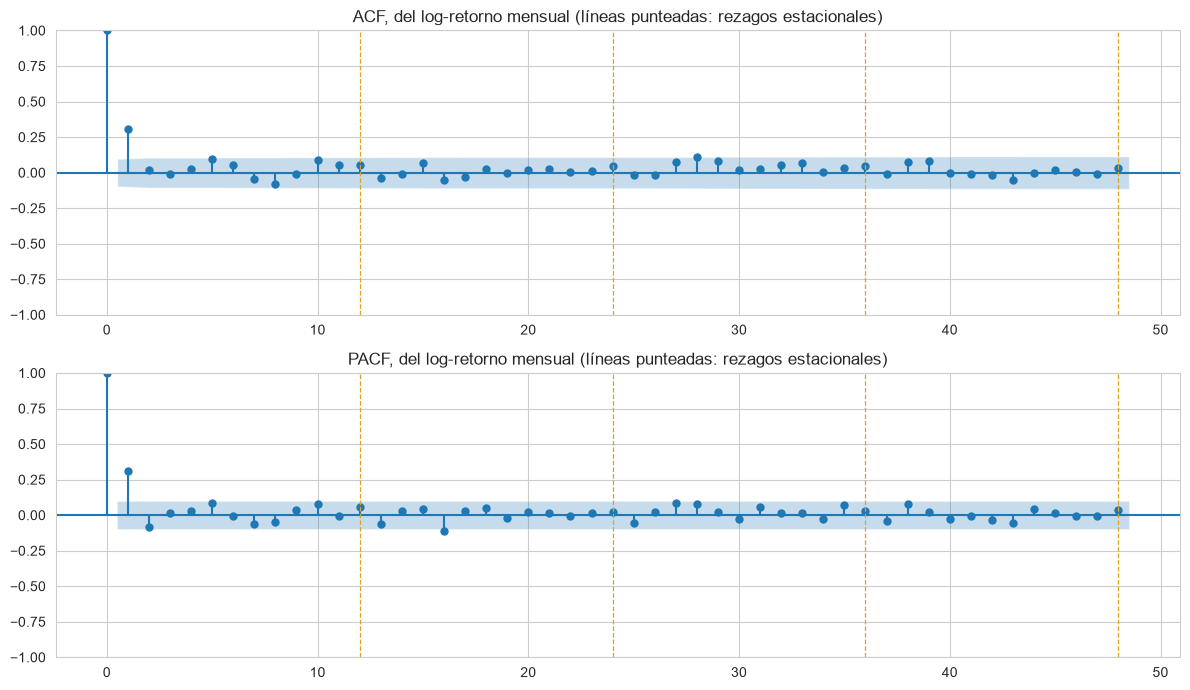

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(y, lags=48, ax=axes[0])
plot_pacf(y, lags=48, ax=axes[1])

for ax, nombre in zip(axes, ["ACF", "PACF"]):
    for k in (12, 24, 36, 48):
        ax.axvline(k, color="goldenrod", linestyle="--", linewidth=0.9)
    ax.set_title(f"{nombre}, del log-retorno mensual (líneas punteadas: rezagos estacionales)")

plt.tight_layout()
plt.savefig("../reports/figures/13_acf_pacf_estacional.png", dpi=150)
plt.show()

In [15]:
n = len(y)
banda = 1.96 / np.sqrt(n)
a = acf(y, nlags=48)
p = pacf(y, nlags=48)

tabla_rezagos = pd.DataFrame({"rezago":[1, 12, 24, 36, 48],
                              "tipo": ["simple"] + ["estacional"] * 4})
tabla_rezagos["ACF"] = [round(a[k], 4) for k in tabla_rezagos["rezago"]]
tabla_rezagos["PACF"] = [round(p[k], 4) for k in tabla_rezagos["rezago"]]

print(f"n = {n} | umbral de significancia = ±{banda:.4f}\n")
print(tabla_rezagos.to_string(index=False))

sig_acf = [k for k in range(1, 49) if abs(a[k]) > banda]
sig_pacf = [k for k in range(1, 49) if abs(p[k]) > banda]
print(f"\nRezagos fuera del umbral (de 48) -> ACF: {sig_acf} | PACF: {sig_pacf}")
print(f"Rezagos esperados fuera del umbral por azar, al 5%: {0.05 * 48:.1f} por función")

n = 415 | umbral de significancia = ±0.0962

 rezago       tipo    ACF   PACF
      1     simple 0.3087 0.3094
     12 estacional 0.0536 0.0591
     24 estacional 0.0431 0.0234
     36 estacional 0.0434 0.0350
     48 estacional 0.0323 0.0381

Rezagos fuera del umbral (de 48) -> ACF: [1, 28] | PACF: [1, 16]
Rezagos esperados fuera del umbral por azar, al 5%: 2.4 por función


**Interpretación:** Con lo que respecta a los rezagos simples, tanto la ACF como la PACF presentan un coeficiente dominante en el primer rezago, con valores de 0.3087 y 0.3094, lo que indica una estructura de orden uno en la parte regular, igual a lo que se identificó en la unidad 2. Por otro lado,  en los rezagos estacionales 12, 24, 36, y 48 ningún coeficiente supera el umbral de ±0.0962, siendo el mayor PACF en el rezago 12 con 0.0591. A pesar de esto, fuera del primer rezago aparecen dos valores aislados por encima del umbral, el rezago de 28 en la ACF y el 16 en la PACF, sin embargo, con 48 rezagos evaluados el 5 % se esperan 2.4 por azar en cada función y ninguno de los dos corresponde a un múltiplo de 12, por lo que no constituye evidencia de un patrón estacional.

## 1.3 ¿Requiere la serie una diferenciación estacional?

Dado que la ACF no muestra picos en los rezagos estacionales, se evalúa de manera formal si es necesario aplicar una diferenciación estacional $D = 1$. Para esto se contrastan dos elementos, por un lado la prueba de Kruskal-Wallis, que compara la distribución del log-retorno entre los doce meses del año sin suponer normalidad (Kruskal-Wallis, 1952), y por otor lado, el efecto que tendría imponer $D = 1$ sobre la serie. 


In [16]:
# Efecto calendario: distribución del log-retorno por mes del año
grupos = [y[y.index.month == mes] for mes in range(1, 13)]
kw = stats.kruskal(*grupos)
print(f"Kruskal-Wallis por mes: H = {kw.statistic:.2f} | p-valor = {kw.pvalue:.4f}")

# Consecuencia de imponer una diferencia estacional (D = 1) sobre esta serie
y_D = X.diff().diff(12).dropna()
print(f"ACF en el rezago 12 con d = 1 y D = 1: {acf(y_D, nlags=12)[12]:.4f}")

modelo_D = SARIMAX(X, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
print(f"Coeficiente MA estacional estimado con D = 1: {modelo_D.params['ma.S.L12']:.4f}")

Kruskal-Wallis por mes: H = 16.54 | p-valor = 0.1221
ACF en el rezago 12 con d = 1 y D = 1: -0.4831
Coeficiente MA estacional estimado con D = 1: -0.9128


**Interpretación:** La prueba de Kruskal-Wallis no rechaza la igualdad de las distribuciones entre meses, con un p-valor de 0.1221, lo que quiere decir que no existe evidencia de un efecto calendario en el log-retorno mensual. Por otro lado, al imponer $D=1$ la ACF en el rezago 12 toma un valor de -0.4831, cercano al -0.5 que se obtiene por construcción al diferenciar estacionalmente una serie sin componente estacional, ya que la covarianza entre $\varepsilon_t-\varepsilon_{t-12}$ y $\varepsilon_{t-12}-\varepsilon_{t-24}$ es $-\sigma^2$ mientras que la varianza de cada termino es $2\sigma^2$. Además, el coeficiente MA estacional estimado es de -0.9128, próximo a -1, siendo este el síntoma característico de una sobre diferenciación, que introduce una raíz unitaria en la parte de media móvil (Plosser & Schwert, 1997). Teniendo en cuenta lo anterior, se fija $D=0$. 

## 1.4 Modelos candidatos y su expresión matemática
Con lo que respecta a la selección de candidatos, esta se acota a lo observado en ACF y PACF. Por un lado, en la parte regular el único rezago significativo es el primero, por lo que los órdenes se limitan a $p, q \in \{0,1\}$. Mientras que en la parte estacional no se observan coeficientes significativos, sin embargo, se incluyen los órdenes $P, Q \in \{0,1\}$ con el fin de verificar de manera formal que el componente estacional no aporta a la especificación, además, la diferenciación se mantiene en $d=1$ y $D=0$ por lo obtenido en las secciones 1.1 y 1.3. De esta forma, la grilla contiene 16 especificaciones, entre ellas la caminata aleatoria con deriva, ARIMA(0,1,0).

La forma general de estos modelos corresponde a un SARIMA$(p,d,q)(P,D,Q)_s$ (Box et al., 2015):

$$\phi(L)\,\Phi(L^s)\,(1-L)^d\,(1-L^s)^D X_t = c + \theta(L)\,\Theta(L^s)\,\varepsilon_t$$

Donde $L$ es el operador de rezago, $\phi(L)$ y $\theta(L)$ son los polinomios autorregresivos y de media móvil de la parte regular, $\Phi(L^s)$ y $\Theta(L^s)$ los de la parte estacional con $s=12$, $c$ es la contante y $\varepsilon_t$ es ruido blanco. Cuando $P=Q=D=0$ la expresión se reduce a un ARIMA$(p,d,q)$.


# 2. Estimación

## 2.1 Grilla de modelos candidatos 

En este caso, cada especificación se compara mediante log-verosimilitud, que mide el ajuste y los criterios de información de Akaike (1974) y de Schwarz (1979), que penalizan el número de parámetros, siendo Schwarz el más severo. A partir de esto, se obtiene como resultado una tabla que se ordena por BIC y reporta los coeficientes que no alcanzan una significancia al 5 %.

In [17]:
filas = []

for p_ord, q_ord, P, Q, in itertools.product((0, 1), repeat=4):
    ajuste = SARIMAX(X, order=(p_ord, 1, q_ord), seasonal_order=(P, 0, Q, 12),
                     trend="c").fit(disp=False)
    coef = ajuste.pvalues.drop("sigma2")
    nombre = (f"ARIMA({p_ord},1,{q_ord})" if P == Q == 0
              else f"SARIMA({p_ord},1,{q_ord})({P},0,{Q})12")
    filas.append({
        "Modelo": nombre,
        "k": len(ajuste.params),
        "Log-verosimilitud": round(ajuste.llf, 2),
        "AIC": round(ajuste.aic, 2),
        "BIC": round(ajuste.bic, 2),
        "Coef. no significativos": ", ".join(coef.index[coef>=0.05]) or "ninguno"
    })

grilla = pd.DataFrame(filas).sort_values("BIC").reset_index(drop=True)
print("k: número de parámetros estimados, incluida la varianza del error\n")
print(grilla.to_string(index=False))

k: número de parámetros estimados, incluida la varianza del error

                Modelo  k  Log-verosimilitud     AIC     BIC    Coef. no significativos
          ARIMA(0,1,1)  3           -1007.93 2021.87 2033.95                    ninguno
          ARIMA(1,1,0)  3           -1009.09 2024.17 2036.26                  intercept
SARIMA(0,1,1)(1,0,0)12  4           -1007.01 2022.02 2038.13        intercept, ar.S.L12
SARIMA(0,1,1)(0,0,1)12  4           -1007.09 2022.18 2038.29        intercept, ma.S.L12
          ARIMA(1,1,1)  4           -1007.74 2023.48 2039.59           intercept, ar.L1
SARIMA(1,1,0)(1,0,0)12  4           -1008.36 2024.71 2040.83        intercept, ar.S.L12
SARIMA(0,1,1)(1,0,1)12  5           -1005.36 2020.71 2040.85                  intercept
SARIMA(1,1,0)(0,0,1)12  4           -1008.42 2024.85 2040.96        intercept, ma.S.L12
SARIMA(1,1,0)(1,0,1)12  5           -1006.69 2023.38 2043.52                  intercept
SARIMA(1,1,1)(1,0,0)12  5           -1006.83 2023.67 

**Interpretación:** A partir de los resultados observados en la tabla se puede determinar que el modelo que encabeza la grilla por BIC, es un ARIMA(0,1,1) con un valor de 2033.95, que junto con la caminata aleatoria, son los únicos modelos en los que todos los coeficientes resultan significativos . Por otor lado, el menor AIC corresponde al modelo SARIMA(0,1,1)(1,0,1)12, con 2020.71 sin embargo, su BIC de 2040.85 lo ubica en el séptimo lugar, lo anterior indica que la mejora en el ajuste no compensa los parámetros adicionales. Con lo que respecta a la caminata aleatoria, esta presenta el menor ajuste de los modelos sin un componente estacional, con una log-verosimilitud de -1020.17 frente a -1007.93 del modelo ARIMA(0,1,1), lo que confirma que el término de media móvil captura una estructura presente en la muestra.

## 2.2 Pruebas de razón de verosimilitud

En cuanto a los modelos anidados, la diferencia en log-verosimilitud se evalúa mediante la prueba de razón de verosimilitud, cuyo estadístico $LR = 2(\ell_{general} - \ell_{restringido})$ sigue una distribución chi-cuadrado de forma asintótica con tantos grados de libertad como parámetros adicionales tenga el modelo general (Wilks, 1938). Con lo que respecta al ARIMA(0,1,1) se contrastan tres elementos, los términos estacionales, un término AR regular y la constante.

In [18]:
def razon_verosimilitud(restringido, general, contraste):
    lr = 2 * (general.llf - restringido.llf)
    gl = len(general.params) - len(restringido.params)
    return {"Contraste": contraste, "LR": round(lr, 3), "gl": gl,
            "p-valor": round(stats.chi2.sf(lr, gl), 4)}

arima_011 = SARIMAX(X, order=(0, 1, 1), trend="c").fit(disp=False)
arima_011_sin_c = SARIMAX(X, order=(0, 1, 1), trend="n").fit(disp=False)
arima_111 = SARIMAX(X, order=(1, 1, 1), trend="c").fit(disp=False)
sarima_101 = SARIMAX(X, order=(0, 1, 1), seasonal_order=(1, 0, 1, 12), trend="c").fit(disp=False)

print(pd.DataFrame([
    razon_verosimilitud(arima_011, sarima_101, "AR y MA estacionales"),
    razon_verosimilitud(arima_011, arima_111, "AR regular"),
    razon_verosimilitud(arima_011_sin_c, arima_011, "Constante"),
]).to_string(index=False))

print("\nCoeficientes estacionales del SARIMA(0,1,1)(1,0,1)12:")
print(sarima_101.params[["ar.S.L12", "ma.S.L12"]].round(4).to_string())
print(f"\nSin constante -> AIC = {arima_011_sin_c.aic:.2f} | BIC = {arima_011_sin_c.bic:.2f}")
print(f"Con constante -> AIC = {arima_011.aic:.2f} | BIC = {arima_011.bic:.2f}")

           Contraste    LR  gl  p-valor
AR y MA estacionales 5.154   2   0.0760
          AR regular 0.389   1   0.5326
           Constante 4.817   1   0.0282

Coeficientes estacionales del SARIMA(0,1,1)(1,0,1)12:
ar.S.L12    0.8377
ma.S.L12   -0.7751

Sin constante -> AIC = 2024.68 | BIC = 2032.74
Con constante -> AIC = 2021.87 | BIC = 2033.95


**Interpretación:** Con lo que respecta a los términos estacionales, se evidencia que estos no resultan significativos en conjunto, con un p-valor de 0.0760 y tampoco el término AR regular, con un p-valor de 0.5326. En el caso del modelo SARIMA(0,1,1)(1,0,1)12, sus coeficientes estacionales de 0.8377 y -0.7751 son de magnitud similar, de tal forma que los factores $(1-0.8377L^{12})$ de la parte autorregresiva y $(1-0.7751L^{12})$ de la parte de media móvil tienden a cancelarse, siendo esta una señal de redundancia de parámetros (Box et al., 2015) que explica por qué el menor AIC de la grilla se traduce en una especificación útil.

Por otro lado, la constante si resulta significativa, con un p-valor de 0.0282 y su inclusión reduce el AIC de 2024.68 a 2021.87, mientras que el BIC aumenta ligeramente de 2032.74 a 2033.95, lo cual se debe a la mayor penalización que este criterio aplica por parámetro. Teniendo en cuenta que la prueba de razón de verosimilitud y de AIC favorecen la constante, esta se conserva en el modelo, lo cual mantiene además la especificación seleccionada en la unidad 2.


## 2.3 Modelo seleccionado

In [19]:
modelo_media = arima_011
print(modelo_media.summary().tables[1])
print(f"\nLog-verosimilitud = {modelo_media.llf:.2f} | AIC = {modelo_media.aic:.2f} | BIC = {modelo_media.bic:.2f}")

# Autocorrelación de primer orden implicada por el MA(1): theta / (1 + theta^2)
theta = modelo_media.params["ma.L1"]
print(f"ACF(1) implicada por el modelo: {theta / (1 + theta**2):.4f} | ACF(1) observada: {a[1]:.4f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3946      0.191      2.067      0.039       0.020       0.769
ma.L1          0.3277      0.036      8.981      0.000       0.256       0.399
sigma2         7.5335      0.379     19.891      0.000       6.791       8.276

Log-verosimilitud = -1007.93 | AIC = 2021.87 | BIC = 2033.95
ACF(1) implicada por el modelo: 0.2959 | ACF(1) observada: 0.3087


**Interpretación:** A partir de los resultados, el modelo seleccionado es un ARIMA(0, 1, 1) con constante, cuyos coeficientes resultan significativos al 5 %, con un término de media móvil de 0.3277 y una constante de 0.3946, lo cual representa la depreciación promedio mensual del peso en el periodo analizado. Remplazando los valores estimados en la forma general de la sección 1.4 con $p=0$, $d=1$ y $q=1$, se obtiene el modelo resultante

$$(1-L)X_t = 0.3946 + (1+0.3277L)\,\varepsilon_t$$

De forma equivalente se expresa como 

$$X_t = X_{t-1} + 0.3946 + \varepsilon_t + 0.3277\,\varepsilon_{t-1}, \qquad \hat{\sigma}^2 = 7.5335$$

Donde $X_t = 100\log(\overline{TRM}_t)$. A diferencia de lo observado en la unidad 2, la constante pasa a ser significativa, con un p-valor de 0.039 frente a 0.061, cambio que se relaciona con la exclusión del mes incompleto de noviembre de 1991 y su log-retorno de -9.64. Adicionalmente, la autocorrelación de primer orden que implica el modelo, $\theta/(1+\theta^2)$ (Box et al., 2015), es de 0.2959, cercana tanto a la observada de 0.3087 como al 0.25 que predice el efeto de agregación temporal (Working, 1960).

---
# 3. Diagnóstico

## 3.1 Autocorrelación y normalidad de residuos

Partiendo del supuesto de que, si el modelo está bien especificado, sus residuos deben comportarse como ruido blanco(Box et al., 2015), se realiza la prueba de Ljung-Box con la finalidad de determinar si los residuos son independientes entre sí. Para esta prueba, los grados de libertad se ajustan restando el número de parámetros ARMA estimados (Ljung & Box, 1978), que en este caso corresponde a uno, dado que el modelo solo incluye el término de media móvil. Por otor lado, de forma complementaria se evalúa la normalidad de los residuos mediante la prueba de Jarque-Bera.

In [20]:
# La primera observación corresponde a la inicialización del nivel y se excluye
residuos = modelo_media.resid.iloc[1:]

lb = acorr_ljungbox(residuos, lags=[6, 12, 18, 24], model_df=1, return_df=True)
lb["decision"] = np.where(lb["lb_pvalue"] >= 0.05, "No rechaza H0", "Rechaza H0")
print("Ljung-Box, H0: residuos independientes (grados de libertad ajustados por el MA(1))\n")
print(lb.round(4).to_string())

jb_stat, jb_p, asimetria, curtosis = jarque_bera(residuos)
print(f"\nJarque-Bera = {jb_stat:.2f} | p-valor = {jb_p:.4f}")
print(f"Asimetría = {asimetria:.4f} | Curtosis = {curtosis:.4f} (3 en la normal)")

Ljung-Box, H0: residuos independientes (grados de libertad ajustados por el MA(1))

    lb_stat  lb_pvalue       decision
6    3.8047     0.5779  No rechaza H0
12  12.1045     0.3558  No rechaza H0
18  20.6711     0.2413  No rechaza H0
24  22.3582     0.4987  No rechaza H0

Jarque-Bera = 106.37 | p-valor = 0.0000
Asimetría = 0.5851 | Curtosis = 5.1867 (3 en la normal)


**Interpretación:** A partir de los resultados de la prueba de Ljung-Box no se rechaza la independencia de los residuos en ninguno de los cuatro rezagos evaluados, con p-valores entre 0.2413 y 0.5779, por lo que el modelo ARIMA(0,1,1) tiene la capacidad de capturar la estructura de dependencia de la media. A pesar de esto, los resultados de la prueba de Jarque-Bera rechazan la normalidad con un p-valor inferior a 0.001, esto debido a que la asimetría de 0.5851 y la curtosis de 5.1867 se alejan de los valores de 0 y 3 esperado en una distribución normal, este resultado es consistente con las colas pesadas documentadas en los retornos financieros (Mandelbrot, 1963; Cont, 2001) y con lo encontrado en unidad 2.

## 3.2 Efectos ARCH en los residuos

En la unidad 2 se observaron algunos tramos en los que la amplitud de los residuos de la serie era visiblemente mayor, este comportamiento corresponde al agrupamiento de volatilidad (Cont, 2001). Para hacer una verificación formal de lo previamente mencionado, se aplican dos pruebas, por un lado la prueba ARCH-LM, la cual evalúa si los residuos al cuadrado dependen de sus propios rezagos (Engle, 1982) y por otro lado, la prueba de Ljung-Box sobre los residuos al cuadrado propuestas por McLeod y Li (1983).

In [21]:
lm_stat, lm_p, _, _ = het_arch(residuos, nlags=12)
print(f"ARCH-LM (12 rezagos): estadístico = {lm_stat:.2f} | p-valor = {lm_p:.4f}\n")

ml = acorr_ljungbox(residuos**2, lags=[6, 12], return_df=True)
print("Ljung-Box sobre los residuos al cuadrado (McLeod-Li):")
print(ml.round(4).to_string())

ARCH-LM (12 rezagos): estadístico = 29.60 | p-valor = 0.0032

Ljung-Box sobre los residuos al cuadrado (McLeod-Li):
    lb_stat  lb_pvalue
6   29.7133        0.0
12  51.6705        0.0


**Interpretación:** Ambas pruebas rechazan la ausencia de efectos ARCH, la prueba ARCH-LM con un p-valor de 0.0032 y la de McLeod-Li con p-valores inferiores a 0.001 en los rezagos 6 y 12. Lo anterior quiere decir que, aunque los residuos no están correlacionados, sus magnitudes sí lo están, por lo que la varianza del error cambia en el tiempo y el supuesto de varianza constante del ARIMA no se cumple. Teniendo esto en cuenta, se incorpora un modelo GARCH para la varianza condicional, tal como se planteó en el trabajo futuro de la unidad 2.

## 3.3 Modelo GARCH(1,1)

En relación con el modelo GARCH(1, 1), es de interes saber que en este modelo se expresa tanto la varianza condicional del error como función del choque, como la varianza del periodo anterior (Bollerslev, 1986):

$$\varepsilon_t = \sigma_t z_t, \qquad \sigma_t^2 = \omega + \alpha\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2$$

Con $\omega > 0$, $\alpha, \beta \geq 0$ y $\alpha + \beta < 1$ para que la varianza no condicional sea finita. Dado que los residuos presentan colas pesadas, se contrasta una distribución normal para $z_t$ frente a una t de student estandarizada, propuesta para los retornos de precios especulativos (Bollerslev, 1987). Finalmente, el modelo se estima en dos etapas, primero la media con el ARIMA(0,1,1) y luego el GARCH sobre sus residuos, ya que la librería arch no admite términos de media móvil en la evaluación media.

In [22]:
comparacion_garch = []
ajustes_garch = {}
for dist, nombre in [("normal", "Normal"), ("t", "t de Student")]:
    g = arch_model(residuos, mean="Zero", vol="GARCH", p=1, q=1, dist=dist).fit(disp="off")
    ajustes_garch[dist] = g
    comparacion_garch.append({"Innovaciones": nombre, "Log-verosimilitud": round(g.loglikelihood, 2),
                              "AIC": round(g.aic, 2), "BIC": round(g.bic, 2)})
print(pd.DataFrame(comparacion_garch).to_string(index=False))

garch = ajustes_garch["t"]
tabla_garch = pd.DataFrame({"coef": garch.params, "p-valor": garch.pvalues}).round(4)
print("\nGARCH(1,1) con innovaciones t de Student:")
print(tabla_garch.to_string())
print(f"\nPersistencia alpha + beta = {garch.params['alpha[1]'] + garch.params['beta[1]']:.4f}")

Innovaciones  Log-verosimilitud     AIC     BIC
      Normal            -979.05 1964.10 1976.18
t de Student            -967.96 1943.92 1960.04

GARCH(1,1) con innovaciones t de Student:
            coef  p-valor
omega     0.3084   0.0936
alpha[1]  0.1672   0.0089
beta[1]   0.8108   0.0000
nu        6.3029   0.0001

Persistencia alpha + beta = 0.9780


**Interpretación:** Al realizar la comparación de las dos distribuciones, se observa que la t de Student presenta mejores valores en los tres criterios, con una log-verosimilitud de -967.96 frente -979.05 y un BIC de 1960.04 frente a 1976.18, teniendo en cuenta estos resultados, se adopta para el modelo final. Con respecto a los parámetros, $\alpha$ de 0.1672 y $\beta$ de 0.8108 resultan significativos, con p-valores de 0.0089 e inferior a 0.001, mientras que $\omega$ no alcanzó el umbral del 5 %, con un p-valor de 0.0936. Finalmente, la presencia de  $\alpha+\beta$ es de 0.9780, la cual es cercana a 1 pero inferior a ella, lo que quiere decir que un choque de volatilidad se disipa lentamente , y los grados de libertad de 6.3030 confirman colas más pesadas que las de una distribución norma. 

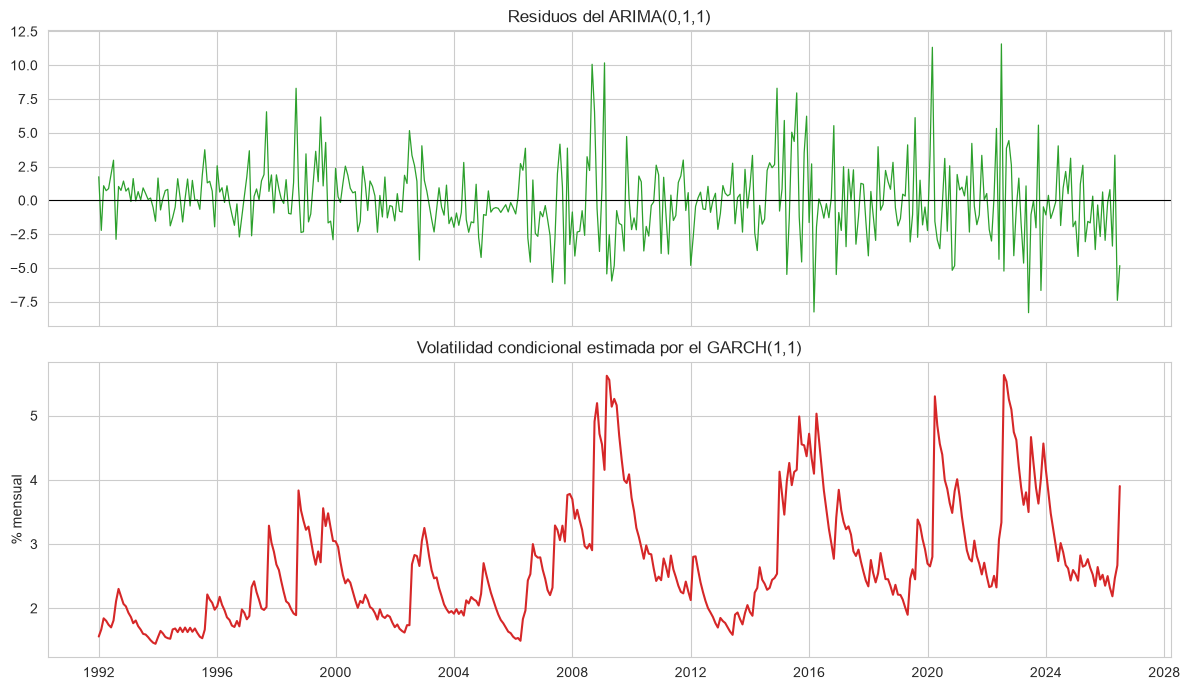

Ljung-Box(12) residuos estandarizados: p = 0.3360
Ljung-Box(12) residuos estandarizados al cuadrado: p = 0.8630
ARCH-LM(12) residuos estandarizados: p = 0.8835


In [23]:
z = garch.std_resid
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(residuos.index, residuos.values, color="#2ca02c", linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Residuos del ARIMA(0,1,1)")
axes[1].plot(garch.conditional_volatility.index, garch.conditional_volatility.values, color="#d62728")
axes[1].set_title("Volatilidad condicional estimada por el GARCH(1,1)")
axes[1].set_ylabel("% mensual")
plt.tight_layout()
plt.savefig("../reports/figures/14_volatilidad_garch.png", dpi=150)
plt.show()

print(f"Ljung-Box(12) residuos estandarizados: p = {acorr_ljungbox(z, lags=[12], return_df=True)['lb_pvalue'].iloc[0]:.4f}")
print(f"Ljung-Box(12) residuos estandarizados al cuadrado: p = {acorr_ljungbox(z**2, lags=[12], return_df=True)['lb_pvalue'].iloc[0]:.4f}")
print(f"ARCH-LM(12) residuos estandarizados: p = {het_arch(z, nlags=12)[1]:.4f}")

Interpretación: A partir de la gráfica, se puede observar que la volatilidad condicional no es constante, sino que esta aumenta en los tramos donde los residuos presentan mayor amplitud, como se evidencia cerca de 2009, 2016, 2020 y 2022, disminuyendo en los periodos de calma, lo mencionado, coincide con el agrupamiento de volatilidad (Cont, 2001). Por otro lado, los residuos estandarizados ya no presentan dependencia ni en niveles ni al cuadrado, con p-valores de 0.3360 y de 0.8630 en la prueba de Ljung-Box y de 0.8835 en la ARCH-LM, teniendi esto en cuenta, GARCH(1,1) es capaz de capturar la heterocedasticidad condicional que el ARIMA dejaba sin moldear. En conjunto, el modelo final queda compuesto por el ARIMA(0,1,1) y el GARCH(1,1) con innovaciones t para la varianza.

---
# 4. Predicción

## 4.1 Esquema de evaluación

El esquema de evaluación compara tres pronósticos. El primero de estos es la caminata aleatoria, la cual pronostica para cada mes el último valor observado y constituye la referencia habitual para tasas de cambio, ya que los modelos estructurales no logran superarla fuera de la muestra (Meese & Rogoff, 1983). El segundo corresponde al modelo del avance 2, el cual fue el ARIMA(0,1,1) con varianza constante y el tercero al modelo final, el cual conserva la misma ecuación para la media y reemplaza la varianza constante pir el GARCH(1,1)-t. Debido a esto, ambos modelos producen el mismo pronóstico puntual y su diferencia se encuentra en los intervalos.

En este caso se realizaron dos ejercicios, por un lado, un pronóstico estático a 12 meses, reservando el último año como conjunto de prueba. Mientras que por otro lado, dado que con 12 observaciones solo se esperan 0.6 casos por fuera de un intervalo del 95 % se evalúan además 120 pronósticos a un paso, que permiten valorar la calibración de los intervalos (Chirstoffersen, 1998). Para finalizar, el error puntual se mide con MAE, RMSE y MAPE sobre la TRM en pesos por dólar (Hyndman & Koehler, 2006) y los intervalos del GARCH se obtienen simulando 5000 trayectorias del modelo.

In [24]:
h = 12
X_train, X_test = X.iloc[:-h], X.iloc[-h:]
real_test = np.exp(X_test / 100)

print(f"Entrenamiento: {X_train.index.min().date()} a {X_train.index.max().date()} ({len(X_train)} meses)")
print(f"Prueba: {X_test.index.min().date()} a {X_test.index.max().date()} ({len(X_test)} meses)")
print(f"Casos esperados fuera de un intervalo del 95 % en la prueba: {0.05 * h:.1f}")

def metricas(real, pronostico):
    return {"MAE": mean_absolute_error(real, pronostico),
            "RMSE": np.sqrt(mean_squared_error(real, pronostico)),
            "MAPE (%)": mean_absolute_percentage_error(real, pronostico) * 100}

def intervalo_garch(media, garch_ajustado, x_ultimo, e_ultimo, pasos, nivel=0.95, n_sim=5000, semilla=2026):
    """Percentiles del nivel de la TRM simulando el ARIMA(0,1,1) con varianza GARCH(1,1)-t."""
    c, th = media.params["intercept"], media.params["ma.L1"]
    # Choques t de Student estandarizados con semilla fija, para que la simulación sea reproducible
    nu_g = garch_ajustado.params["nu"]
    generador = np.random.default_rng(semilla)
    choques = lambda tamano: generador.standard_t(nu_g, tamano) * np.sqrt((nu_g - 2) / nu_g)
    sim = garch_ajustado.forecast(horizon=pasos, method="simulation", simulations=n_sim,
                                  reindex=False, rng=choques)
    e = sim.simulations.residuals[-1]                      # (n_sim, pasos)
    e_previo = np.column_stack([np.full(n_sim, e_ultimo), e[:, :-1]])
    trayectorias = x_ultimo + np.cumsum(c + e + th * e_previo, axis=1)
    cola = (1 - nivel) / 2 * 100
    return (np.exp(np.percentile(trayectorias, cola, axis=0) / 100),
            np.exp(np.percentile(trayectorias, 100 - cola, axis=0) / 100))

Entrenamiento: 1991-12-01 a 2025-07-01 (404 meses)
Prueba: 2025-08-01 a 2026-07-01 (12 meses)
Casos esperados fuera de un intervalo del 95 % en la prueba: 0.6


## 4.2 Pronóstico estático a 12 meses

In [25]:
media_train = SARIMAX(X_train, order=(0, 1, 1), trend="c").fit(disp=False)
res_train = media_train.resid.iloc[1:]
garch_train = arch_model(res_train, mean="Zero", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")

f_arima = media_train.get_forecast(steps=h)
pron_arima = np.exp(f_arima.predicted_mean / 100)
ic_arima = np.exp(f_arima.conf_int(alpha=0.05) / 100)
pron_rw = pd.Series(np.exp(X_train.iloc[-1] / 100), index=X_test.index)
inf_g, sup_g = intervalo_garch(media_train, garch_train, X_train.iloc[-1], res_train.iloc[-1], h)

tabla_estatico = pd.DataFrame([
    {"Modelo": "Caminata aleatoria", **metricas(real_test, pron_rw)},
    {"Modelo": "ARIMA(0,1,1) (media del avance 2 y del modelo final)", **metricas(real_test, pron_arima)},
]).round(2)
print(f"Deriva estimada en entrenamiento: {media_train.params['intercept']:.4f} | theta: {media_train.params['ma.L1']:.4f}\n")
print(tabla_estatico.to_string(index=False))

cob_arima = ((real_test >= ic_arima.iloc[:, 0]) & (real_test <= ic_arima.iloc[:, 1])).mean()
cob_garch = ((real_test.values >= inf_g) & (real_test.values <= sup_g)).mean()
print(f"\nIntervalo del 95 % -> varianza constante: cobertura {cob_arima:.1%}, ancho medio "
      f"{(ic_arima.iloc[:, 1] - ic_arima.iloc[:, 0]).mean():.1f} COP")
print(f"Intervalo del 95 % -> GARCH(1,1)-t: cobertura {cob_garch:.1%}, ancho medio {(sup_g - inf_g).mean():.1f} COP")
print(f"\nTRM al cierre del entrenamiento: {np.exp(X_train.iloc[-1] / 100):.2f} | último mes de prueba: {real_test.iloc[-1]:.2f}")
print(f"Volatilidad condicional al cierre del entrenamiento: {garch_train.conditional_volatility.iloc[-1]:.4f} "
      f"| desviación estándar del ARIMA: {np.sqrt(media_train.params['sigma2']):.4f}")

Deriva estimada en entrenamiento: 0.4615 | theta: 0.3315

                                              Modelo    MAE   RMSE  MAPE (%)
                                  Caminata aleatoria 323.38 375.62       9.0
ARIMA(0,1,1) (media del avance 2 y del modelo final) 424.05 493.06      11.8

Intervalo del 95 % -> varianza constante: cobertura 91.7%, ancho medio 1388.8 COP
Intervalo del 95 % -> GARCH(1,1)-t: cobertura 91.7%, ancho medio 1328.7 COP

TRM al cierre del entrenamiento: 4040.85 | último mes de prueba: 3268.95
Volatilidad condicional al cierre del entrenamiento: 2.6142 | desviación estándar del ARIMA: 2.7258


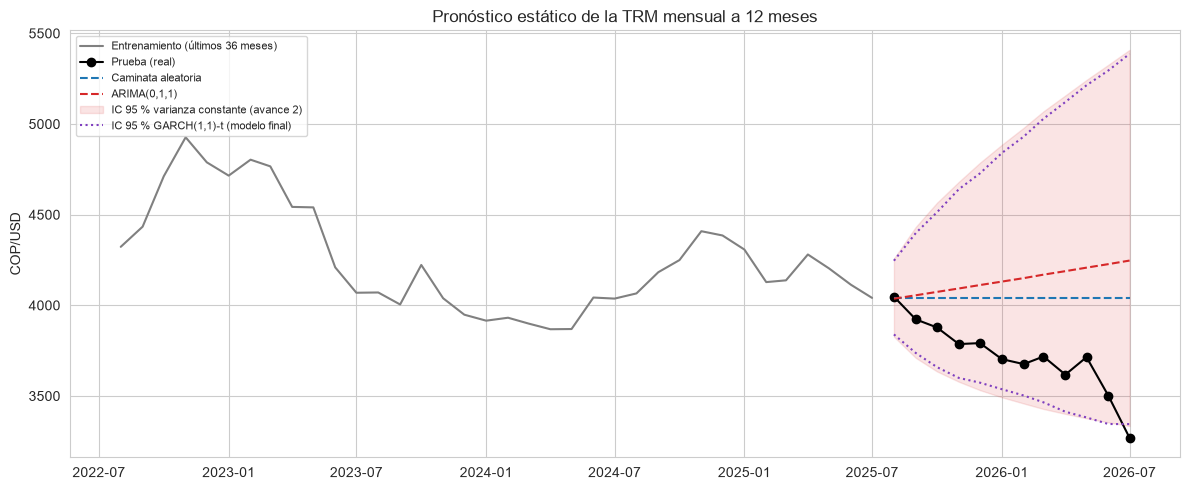

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
hist = np.exp(X_train.iloc[-36:] / 100)
ax.plot(hist.index, hist.values, color="gray", label="Entrenamiento (últimos 36 meses)")
ax.plot(real_test.index, real_test.values, color="black", marker="o", label="Prueba (real)")
ax.plot(pron_rw.index, pron_rw.values, "--", color="#1f77b4", label="Caminata aleatoria")
ax.plot(pron_arima.index, pron_arima.values, "--", color="#d62728", label="ARIMA(0,1,1)")
ax.fill_between(ic_arima.index, ic_arima.iloc[:, 0], ic_arima.iloc[:, 1], color="#d62728", alpha=0.12,
                label="IC 95 % varianza constante (avance 2)")
ax.plot(real_test.index, inf_g, ":", color="#7f3fbf", label="IC 95 % GARCH(1,1)-t (modelo final)")
ax.plot(real_test.index, sup_g, ":", color="#7f3fbf")
ax.set_title("Pronóstico estático de la TRM mensual a 12 meses")
ax.set_ylabel("COP/USD")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/15_pronostico_prueba.png", dpi=150)
plt.show()

**Interpretación:** A partir de las gráficas se observa que el conjunto de prueba, comprendido entre agosto de 2025 y julio de 2026,  que la caminata aleatoria obtiene menos errores que el ARIMA(0,1,1) en las tres métricas, con un MAE de 323.38 frente a 424.05 pesos y un MAPE de 9.0 % frente a un 11.8 %. Esto se explica porque la TRM pasó de 4040.85 al cierre del entrenamiento a 3268.95 en el último mes de prueba, mientras que el ARIMA proyecta la deriva de 0.4615 estimada en el entrenamiento, es decir, una depreciación mensual que no ocurrió en ese año. Con lo que respecta a los intervalos, ambos cubren 11 de los 12 meses, con una cobertura de 91.7 %, y el del GARCH resulta ligeramente más angosto, con un ancho medio de 1328.7 frente a 1388.8 pesos, esto debido a que el cierre del entrenamiento la volatilidad condicional, de 2.6142, era inferior a la desviación estándar de 2.7258 que supone ARIMA. En la gráfica se observa demás que el único mes por fuera de ambos intervalos es julio de 2026, en el que la TRM car por debajo del límite inferior.

## 4.3 Pronóstico a un paso sobre los últimos 120 meses

Los parámetros se estiman con datos hasta julio de 2016 y se mantienen fijos, de modo que cada pronóstico utiliza únicamente la información disponible hasta el mes anterior. Además, para comparar la precisión de los dos pronósticos puntuales, se aplica la prueba de Diebold y Mariano (1995), cuya hipótesis nula es que ambos tienen la misma precisión. 

In [27]:
H = 120
X_ini = X.iloc[:-H]
media_ini = SARIMAX(X_ini, order=(0, 1, 1), trend="c").fit(disp=False)
filtro = media_ini.apply(X)          # mismos parámetros; cada pronóstico usa información hasta t-1

pred_1 = filtro.get_prediction(start=X.index[-H])
media_1 = pred_1.predicted_mean
ic_1 = pred_1.conf_int(alpha=0.05)
real_1 = np.exp(X.iloc[-H:] / 100)
rw_1 = np.exp(X.shift(1).iloc[-H:] / 100)

garch_ini = arch_model(media_ini.resid.iloc[1:], mean="Zero", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
sigma_1 = (arch_model(filtro.resid.iloc[1:], mean="Zero", vol="GARCH", p=1, q=1, dist="t")
           .fix(garch_ini.params).conditional_volatility.iloc[-H:])
nu = garch_ini.params["nu"]
escala_t = np.sqrt((nu - 2) / nu)          # la t estandarizada tiene varianza unitaria

print(f"Ventana de evaluación: {X.index[-H].date()} a {X.index[-1].date()} ({H} pronósticos a un paso)")
print(f"Parámetros estimados hasta {X_ini.index[-1].date()} -> theta = {media_ini.params['ma.L1']:.4f}\n")
print(pd.DataFrame([{"Modelo": "Caminata aleatoria", **metricas(real_1, rw_1)},
                    {"Modelo": "ARIMA(0,1,1)", **metricas(real_1, np.exp(media_1 / 100))}]).round(2).to_string(index=False))

filas_ic = []
for nivel in (0.95, 0.99):
    z_n = stats.norm.ppf(0.5 + nivel / 2)
    z_t = stats.t.ppf(0.5 + nivel / 2, nu) * escala_t
    sd_cte = np.sqrt(media_ini.params["sigma2"])
    fuera_cte = (np.abs(X.iloc[-H:] - media_1) > z_n * sd_cte).mean()
    fuera_g = (np.abs(X.iloc[-H:] - media_1) > z_t * sigma_1).mean()
    ancho_cte = (np.exp((media_1 + z_n * sd_cte) / 100) - np.exp((media_1 - z_n * sd_cte) / 100)).mean()
    ancho_g = (np.exp((media_1 + z_t * sigma_1) / 100) - np.exp((media_1 - z_t * sigma_1) / 100)).mean()
    filas_ic.append({"Nivel": f"{nivel:.0%}", "Esperado fuera": f"{1 - nivel:.1%}",
                     "Fuera var. constante": f"{fuera_cte:.1%}", "Fuera GARCH-t": f"{fuera_g:.1%}",
                     "Ancho var. constante": round(ancho_cte, 1), "Ancho GARCH-t": round(ancho_g, 1)})
print("\n" + pd.DataFrame(filas_ic).to_string(index=False))

Ventana de evaluación: 2016-08-01 a 2026-07-01 (120 pronósticos a un paso)
Parámetros estimados hasta 2016-07-01 -> theta = 0.4603

            Modelo   MAE   RMSE  MAPE (%)
Caminata aleatoria 87.33 118.72      2.34
      ARIMA(0,1,1) 94.42 128.85      2.52

Nivel Esperado fuera Fuera var. constante Fuera GARCH-t  Ancho var. constante  Ancho GARCH-t
  95%           5.0%                11.7%          6.7%                 362.6          471.5
  99%           1.0%                 5.0%          1.7%                 476.6          705.0


In [28]:
def diebold_mariano(e1, e2, perdida):
    """Prueba de Diebold-Mariano a un paso; H0: igual precisión."""
    d = perdida(e1) - perdida(e2)
    estadistico = d.mean() / np.sqrt(d.var(ddof=1) / len(d))
    return estadistico, 2 * stats.norm.sf(abs(estadistico))

e_arima = real_1 - np.exp(media_1 / 100)
e_rw = real_1 - rw_1
for nombre, perdida in [("absoluta", np.abs), ("cuadrática", np.square)]:
    dm, p_dm = diebold_mariano(e_arima, e_rw, perdida)
    print(f"Diebold-Mariano, pérdida {nombre}: DM = {dm:.3f} | p-valor = {p_dm:.4f}")

Diebold-Mariano, pérdida absoluta: DM = 1.409 | p-valor = 0.1588
Diebold-Mariano, pérdida cuadrática: DM = 1.470 | p-valor = 0.1417


**Interpretación:** Al evaluar 120 pronósticos a un paso, entre agosto de 2016 y julio de 2026, la caminata aleatoria vuelve a presentar menores errores, con un MAE de 87.33 frente a 94.42 pesos y un RMSE de 118.72 frente a 128.85. A pesar de esto, la prueba de Diebold-Mariano no rechaza la igualdad de precisión, con p-valores de 0.1588 para la perdida absoluta y 0.1417 para la cuadrática, esto quiere decir que no es posible afirmar que alguno de los dos pronósticos sea más preciso.


Por otro lado, es en los intervalos donde el modelo final marca la diferencia, ya que con varianza constante el 11.7 % de las observaciones queda fuera del intervalo del 95 %, más del doble del 5.0 % esperado, mientras que con el GARCH(1,1)-t esta proporción es de 6.7 %. Además, al 99 % el contraste es similar, con 5.0 % frente a 1.7 % cuando se esperaba 1.0 %. Esta mejora se obtiene con intervalos más anchos en promedio, de 471.5 frente a 362.6 pesos al 95 % por lo que el GARCH no reduce la incertidumbre, sino que la representa de forma más fiel, ampliando el intervalo en los periodos de mayor volatilidad.

## 4.4 Estabilidad de la estructura de media móvil

Para explicar por qué ARIMA(0,1,1) no supera a la caminata aleatoria, se compara la autocorrelación de primer orden del log-retorno en el periodo utilizado para estimar los parámetros y en el periodo de evaluación. 

In [29]:
for inicio, fin in [("1992-01", "2016-07"), ("2016-08", "2026-07")]:
    tramo = y.loc[inicio:fin]
    print(f"{inicio} a {fin}: n = {len(tramo)} | ACF(1) = {acf(tramo, nlags=1)[1]:.4f} "
          f"| umbral = ±{1.96 / np.sqrt(len(tramo)):.4f}")

1992-01 a 2016-07: n = 295 | ACF(1) = 0.4144 | umbral = ±0.1141
2016-08 a 2026-07: n = 120 | ACF(1) = 0.0906 | umbral = ±0.1789


**Interpretación:** La autocorrelación de primer orden se pasa de 0.4144 entre 1992 y julio de 2016 a 0.0906 entre agosto de 2016 y julio de 2026, valor que ya no supera el umbral de ±0.1789 de ese tramo. Teniendo en cuenta lo anterior, el modelo estimado con los datos hasta 2016, con un coeficiente de media móvil de 0.4603, trasladó el periodo de evaluación una dependencia que en él se debilitó, lo que explica que sus pronósticos no superen a los de caminata aleatoria. Este resultado es consistente con la literatura sobre tasas de cambio, en la que la capacidad predictiva de los modelos resulta inestable en tiempo (Rossi, 2013), y constituye un matiz sobre la conclusión de la unidad 2, ya que la estructura MA(1) existe en la muestra completa pero no se mantiene con la misma intensidad en última década. Finalmente, cabe resaltar que la distancia entre 0.0906 y el 0.25 que predice la agregación temporal (Working, 1960) es inferior al umbral de ese tramo, por lo que con 120 observaciones los datos no permiten distinguir con precisión entre ese valor y la ausencia de autocorrelación.

## 4.5 Pronóstico de los próximos 12 meses

Con el modelo final estimado sobre toda la serie se genera el pronóstico entre agosto de 20226 y julio de 2027, junto con los intervalos de 95 % bajo varianza constante y bajo el GARCH(1,1)-t.

In [30]:
garch_final = garch                                   # ajustado sobre toda la serie en la sección 3
f_final = modelo_media.get_forecast(steps=12)
pron_final = np.exp(f_final.predicted_mean / 100)
ic_final = np.exp(f_final.conf_int(alpha=0.05) / 100)
inf_f, sup_f = intervalo_garch(modelo_media, garch_final, X.iloc[-1], residuos.iloc[-1], 12)

tabla_futuro = pd.DataFrame({
    "Pronóstico": pron_final.round(2),
    "IC 95 % inferior (GARCH-t)": inf_f.round(2),
    "IC 95 % superior (GARCH-t)": sup_f.round(2),
    "Ancho GARCH-t": (sup_f - inf_f).round(2),
    "Ancho var. constante": (ic_final.iloc[:, 1] - ic_final.iloc[:, 0]).round(2),
})
tabla_futuro.index = tabla_futuro.index.strftime("%Y-%m")
print(tabla_futuro.to_string())
print(f"\nResiduo del último mes observado: {residuos.iloc[-1]:.4f}")
print(f"Volatilidad condicional del último mes observado: {garch.conditional_volatility.iloc[-1]:.4f} "
      f"| desviación estándar incondicional del ARIMA: {np.sqrt(modelo_media.params['sigma2']):.4f}")

         Pronóstico  IC 95 % inferior (GARCH-t)  IC 95 % superior (GARCH-t)  Ancho GARCH-t  Ancho var. constante
2026-08     3230.37                     2979.42                     3505.15         525.73                347.73
2026-09     3243.14                     2843.68                     3693.83         850.15                580.76
2026-10     3255.96                     2744.79                     3831.42        1086.63                746.87
2026-11     3268.83                     2666.81                     3986.21        1319.40                884.62
2026-12     3281.76                     2624.07                     4086.80        1462.73               1005.78
2027-01     3294.73                     2583.53                     4220.29        1636.76               1115.77
2027-02     3307.76                     2545.46                     4324.57        1779.11               1217.67
2027-03     3320.84                     2498.59                     4455.98        1957.39      

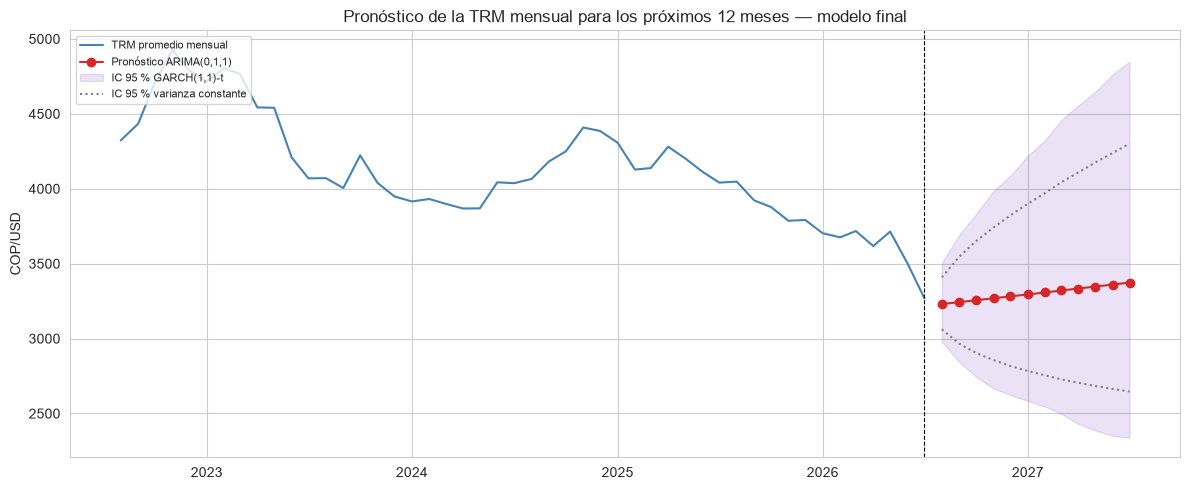

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
hist = np.exp(X.iloc[-48:] / 100)
ax.plot(hist.index, hist.values, color="steelblue", label="TRM promedio mensual")
ax.plot(pron_final.index, pron_final.values, color="#d62728", marker="o", label="Pronóstico ARIMA(0,1,1)")
ax.fill_between(pron_final.index, inf_f, sup_f, color="#7f3fbf", alpha=0.15, label="IC 95 % GARCH(1,1)-t")
ax.plot(ic_final.index, ic_final.iloc[:, 0], ":", color="gray", label="IC 95 % varianza constante")
ax.plot(ic_final.index, ic_final.iloc[:, 1], ":", color="gray")
ax.axvline(X.index[-1], color="black", linestyle="--", linewidth=0.8)
ax.set_title("Pronóstico de la TRM mensual para los próximos 12 meses — modelo final")
ax.set_ylabel("COP/USD")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/16_pronostico_futuro.png", dpi=150)
plt.show()

**Interpretación:** El pronóstico parte de 3230.37 pesos por dólar en agosto de 2026, valor inferior a la TRM de 3268.95 de julio de 2026, esto debido a que el termino de media móvil incorpora parte del residuo negativo de -4.8274 del último mes. A partir del segundo mes el pronóstico aumenta de forma gradual hasta 3373.67 en julio de 2027, siguiendo únicamente la deriva de 0.3946, ya que en un MA(1) el término de media móvil deja de aportar información más allá del primer paso(Box et al., 2015). Por otro lado, los intervalos del GARCH(1,1)-t son más amplios que los obtenidos por varianza constante en todo el horizonte, con un ancho de 525.73 frente a 347.73 pesos en el primer mes, lo cual explica porque la volatilidad condicional del último mes observado es de 3.9039, superior a la desviación estándar de 2.7447 que supone ARIMA. Teniendo en cuenta lo evaluado en la sección 4.3, el intervalo del modelo final es la representación más fiel de la incertidumbre del pronóstico, mientras que el valor puntual debe leerse con la cautela que imponen los resultados frente a la caminata aleatoria.